# **7. Class Imbalance Handling and Model Improvement**

### **Environment Setup**

This notebook investigates the effect of class imbalance handling techniques on the prediction of ten-year coronary heart disease using the Framingham dataset. The baseline Logistic Regression, Random Forest, and XGBoost models are enhanced using class weighting, the Synthetic Minority Over-sampling Technique (SMOTE), and the combined Synthetic Minority Over-sampling Technique with Edited Nearest Neighbours (SMOTE-ENN). Their performance is subsequently compared with the baseline models developed in the previous notebooks to evaluate the effectiveness of each class imbalance handling approach.

### **Library Imports**

The required libraries are imported to support data manipulation, model development, and performance evaluation.

In [34]:
# Import required libraries

import pandas as pd                  # Data manipulation and analysis
import numpy as np                   # Numerical computations
import matplotlib.pyplot as plt      # Data visualization
import seaborn as sns                # Statistical data visualization
import joblib                        # Saving and loading trained models

# Import imbalance handling techniques
from imblearn.over_sampling import SMOTE          # Synthetic Minority Over-sampling Technique
from imblearn.combine import SMOTEENN             # Combined SMOTE and Edited Nearest Neighbours

# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

### **Data Ingestion**

The prepared training and testing datasets were successfully loaded. Both the unscaled and standardized predictor variables were retained because Logistic Regression requires standardized features, whereas the tree-based models use the original unscaled datasets. This ensures that each model is trained using the most appropriate representation of the data while allowing a fair comparison of class imbalance handling techniques.

In [7]:
# Load the unscaled training and testing datasets
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Load the scaled training and testing datasets for Logistic Regression
X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")

# Display dataset dimensions
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3392, 15)
X_test : (848, 15)
y_train: (3392,)
y_test : (848,)


### **Class Distribution Before Resampling**

Before applying any class imbalance handling technique, the distribution of the target classes in the training dataset is examined to assess the extent of class imbalance. Understanding the class distribution provides a baseline for evaluating the effectiveness of the resampling techniques applied later in this notebook.

In [4]:
# Display the class distribution
class_distribution = y_train.value_counts().sort_index()

class_summary = pd.DataFrame({
    "Class": class_distribution.index,
    "Count": class_distribution.values,
    "Percentage (%)": (
        class_distribution.values /
        class_distribution.sum() * 100
    ).round(2)
})

class_summary

,Class,Count,Percentage (%)
0,0,2877,84.82
1,1,515,15.18


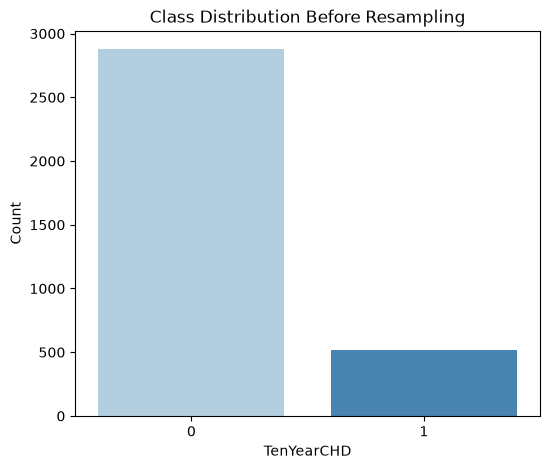

In [5]:
# Visualize the class distribution
plt.figure(figsize=(6, 5))

sns.countplot(
    x=y_train,
    hue=y_train,
    palette="Blues",
    legend=False
)

# Customize the plot
plt.xlabel("TenYearCHD")
plt.ylabel("Count")
plt.title("Class Distribution Before Resampling")

# Display the plot
plt.show()

The class distribution confirms that the training dataset is imbalanced, with 2,877 observations (84.82%) belonging to the majority class (participants who did not develop coronary heart disease) and 515 observations (15.18%) belonging to the minority class (participants who developed coronary heart disease). Such imbalance can bias machine learning models towards the majority class, resulting in poor detection of minority class instances. Consequently, class imbalance handling techniques are explored to improve the identification of participants at risk of developing coronary heart disease while maintaining overall predictive performance.

### **Logistic Regression with Class Weighting**

#### **Model Training**

The Logistic Regression model is trained using balanced class weights while retaining the same model configuration used in the baseline experiment. This enables a direct comparison between the baseline model and the class-weighted model.

In [ ]:
# Initialize the Logistic Regression model with balanced class weights
log_reg_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

# Train the model using the scaled training dataset
log_reg_balanced.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

The Logistic Regression model was successfully trained using balanced class weights and the standardized training dataset. By assigning greater importance to the minority class during training, the model is expected to improve its ability to identify participants who developed coronary heart disease while allowing direct comparison with the baseline Logistic Regression model.

#### **Model Prediction**

The trained class-weighted Logistic Regression model is applied to the standardized testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are used to evaluate the effect of class weighting on the model's ability to identify coronary heart disease cases.

In [10]:
# Generate predicted class labels
y_pred_bal = log_reg_balanced.predict(X_test_scaled)

# Generate predicted probabilities for the positive class
y_pred_proba_bal = log_reg_balanced.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The class-weighted Logistic Regression model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs will be used to assess whether class weighting improves the detection of minority class cases compared with the baseline Logistic Regression model.

#### **Model Performance Evaluation**

The class-weighted Logistic Regression model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. The results are compared with the baseline Logistic Regression model to determine the effect of class weighting on minority class detection.

In [11]:
# Calculate the evaluation metrics
accuracy_bal = accuracy_score(y_test, y_pred_bal)
precision_bal = precision_score(y_test, y_pred_bal)
recall_bal = recall_score(y_test, y_pred_bal)
f1_bal = f1_score(y_test, y_pred_bal)
roc_auc_bal = roc_auc_score(y_test, y_pred_proba_bal)

# Create a summary table
balanced_lr_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_bal, 3),
        round(precision_bal, 3),
        round(recall_bal, 3),
        round(f1_bal, 3),
        round(roc_auc_bal, 3)
    ]
})

balanced_lr_metrics

,Metric,Value
0,Accuracy,0.672
1,Precision,0.254
2,Recall,0.597
3,F1-score,0.356
4,ROC-AUC,0.700


The class-weighted Logistic Regression model substantially improved the detection of participants who developed coronary heart disease. Compared with the baseline Logistic Regression model, recall increased from 0.054 to 0.597, while the F1-score improved from 0.096 to 0.356, indicating a much better balance between precision and recall. Although accuracy decreased from 0.844 to 0.672 and precision declined from 0.412 to 0.254, the ROC-AUC score remained virtually unchanged (0.700 versus 0.702). These findings suggest that class weighting effectively reduced the model's bias towards the majority class, resulting in a considerably greater ability to identify minority class instances at the cost of an increased number of false positive predictions.

#### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes of the class-weighted Logistic Regression model by comparing the predicted class labels with the actual class labels. The results are compared with the baseline Logistic Regression model to assess how class weighting affects the identification of minority class instances.

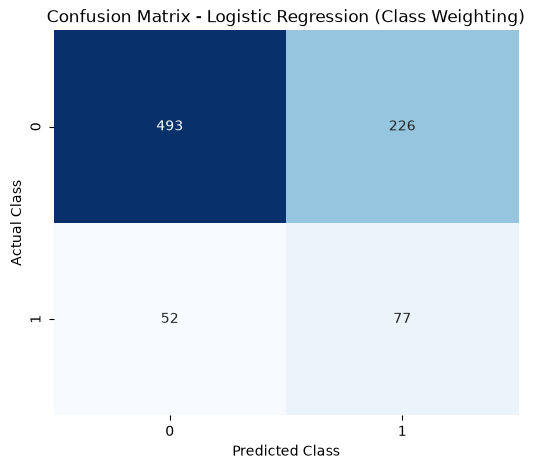

In [12]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_bal)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Logistic Regression (Class Weighting)")

# Display the plot
plt.show()

The confusion matrix demonstrates that class weighting substantially improved the model's ability to identify participants who developed coronary heart disease. Compared with the baseline Logistic Regression model, the number of true positive predictions increased from 7 to 77, while false negatives decreased from 122 to 52. However, this improvement came at the expense of an increase in false positive predictions, which rose from 8 to 226, resulting in fewer correctly classified negative cases. These findings indicate that class weighting successfully reduced the model's bias towards the majority class, improving sensitivity to the minority class while sacrificing overall classification accuracy.

#### **Classification Report**

The classification report provides a detailed summary of the class-weighted Logistic Regression model's performance for each class by presenting precision, recall, F1-score, and support. These metrics facilitate comparison with the baseline Logistic Regression model and provide additional insight into the effect of class weighting on minority class detection.

In [13]:
# Display the classification report
print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.90      0.69      0.78       719
           1       0.25      0.60      0.36       129

    accuracy                           0.67       848
   macro avg       0.58      0.64      0.57       848
weighted avg       0.81      0.67      0.72       848



The classification report indicates that class weighting substantially improved the Logistic Regression model's ability to identify participants who developed coronary heart disease. Compared with the baseline model, the recall of the minority class increased from 0.05 to 0.60, while the F1-score improved from 0.10 to 0.36, demonstrating a much better balance between precision and recall. Although precision decreased from 0.41 to 0.25 due to an increase in false positive predictions, the overall performance for the minority class was markedly better than that of the baseline model. These findings confirm that assigning balanced class weights effectively reduced the model's bias towards the majority class and enhanced its sensitivity to coronary heart disease cases.

#### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is compared with that of the baseline Logistic Regression model to determine whether class weighting improves the model's overall discriminative ability.

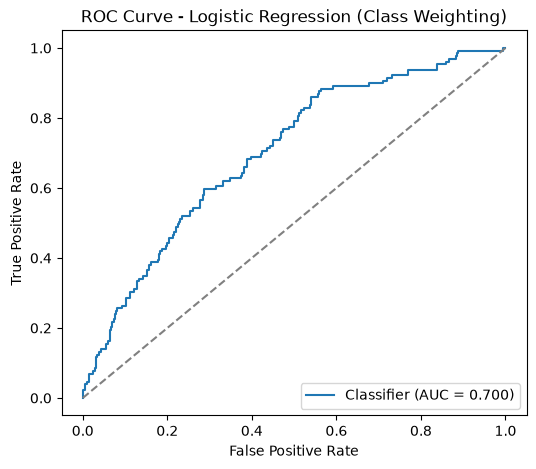

In [14]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_bal)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_bal:.3f})"
)

# Plot the reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Class Weighting)")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the class-weighted Logistic Regression model across different classification thresholds. The model achieved an ROC-AUC score of 0.700, which is virtually identical to the baseline Logistic Regression model (0.702). This indicates that class weighting did not substantially improve the model's overall ability to distinguish between participants who developed coronary heart disease and those who did not. However, despite the similar ROC-AUC score, class weighting greatly improved the model's sensitivity to the minority class, resulting in a substantially higher recall and F1-score. These findings suggest that class weighting primarily altered the model's classification behaviour rather than its overall discriminative capability.

### **Random Forest with Class Weighting**

The Random Forest classifier is retrained using balanced class weights to reduce the influence of class imbalance during model learning. By assigning greater importance to the minority class, the model is expected to improve its ability to identify participants who developed coronary heart disease while allowing direct comparison with the baseline Random Forest model.

#### **Model Training**

The Random Forest model is trained using balanced class weights while retaining the same baseline model configuration. This enables the effect of class weighting on predictive performance to be evaluated independently of other model parameters.

In [ ]:
# Initialize the Random Forest model with balanced class weights
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Train the model using the unscaled training dataset
rf_balanced.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

The Random Forest model was successfully trained using balanced class weights. By assigning greater importance to the minority class during training, the model is expected to improve the detection of participants who developed coronary heart disease while allowing direct comparison with the baseline Random Forest model.

#### **Model Prediction**

The trained class-weighted Random Forest model is applied to the testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are subsequently used to evaluate the impact of class weighting on model performance.

In [17]:
# Generate predicted class labels
y_pred_bal = rf_balanced.predict(X_test)

# Generate predicted probabilities for the positive class
y_pred_proba_bal = rf_balanced.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The class-weighted Random Forest model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs will be used to assess whether class weighting improves the model's ability to identify minority class instances compared with the baseline Random Forest model.

#### **Model Performance Evaluation**

The predictive performance of the class-weighted Random Forest model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. The results are compared with those of the baseline Random Forest model to determine the effectiveness of class weighting in addressing class imbalance.

##### **Performance Metrics**

The evaluation metrics summarize the predictive performance of the class-weighted Random Forest model and facilitate comparison with the baseline Random Forest model.

In [18]:
# Calculate the evaluation metrics
accuracy_bal = accuracy_score(y_test, y_pred_bal)
precision_bal = precision_score(y_test, y_pred_bal)
recall_bal = recall_score(y_test, y_pred_bal)
f1_bal = f1_score(y_test, y_pred_bal)
roc_auc_bal = roc_auc_score(y_test, y_pred_proba_bal)

# Create a summary table
balanced_rf_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_bal, 3),
        round(precision_bal, 3),
        round(recall_bal, 3),
        round(f1_bal, 3),
        round(roc_auc_bal, 3)
    ]
})

balanced_rf_metrics

,Metric,Value
0,Accuracy,0.807
1,Precision,0.278
2,Recall,0.171
3,F1-score,0.212
4,ROC-AUC,0.641


The class-weighted Random Forest model showed a modest improvement in its ability to identify participants who developed coronary heart disease. Compared with the baseline Random Forest model, recall increased from 0.062 to 0.171, while the F1-score improved from 0.111 to 0.212, indicating better detection of minority class instances. However, these improvements were accompanied by reductions in accuracy (0.849 to 0.807) and precision (0.533 to 0.278). The ROC-AUC score remained virtually unchanged, increasing only slightly from 0.639 to 0.641. Overall, class weighting reduced the model's bias towards the majority class but produced only a moderate improvement in identifying coronary heart disease cases compared with the baseline Random Forest model.

#### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes of the class-weighted Random Forest model by comparing the predicted class labels with the actual class labels. The results are compared with those of the baseline Random Forest model to assess the effect of class weighting on minority class detection.

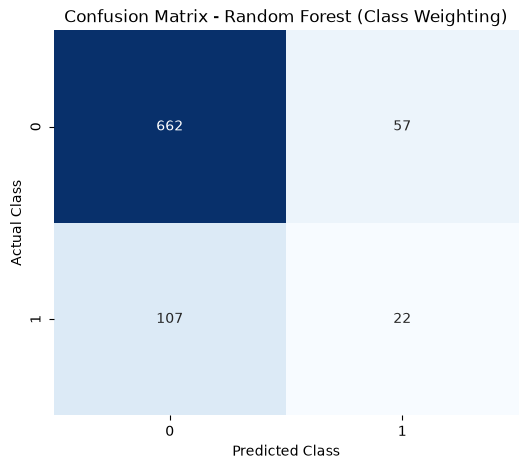

In [19]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_bal)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Random Forest (Class Weighting)")

# Display the plot
plt.show()

The confusion matrix demonstrates that class weighting moderately improved the Random Forest model's ability to identify participants who developed coronary heart disease. Compared with the baseline Random Forest model, the number of true positive predictions increased from 8 to 22, while false negatives decreased from 121 to 107. However, this improvement was accompanied by an increase in false positive predictions, which rose from 7 to 57, resulting in fewer correctly classified negative cases. Overall, class weighting reduced the model's bias towards the majority class and improved sensitivity to the minority class, although the improvement was less pronounced than that observed for the Logistic Regression model.

#### **Classification Report**

The classification report provides a detailed summary of the class-weighted Random Forest model's performance for each class by presenting precision, recall, F1-score, and support. These metrics facilitate comparison with the baseline Random Forest model and provide additional insight into the effect of class weighting on minority class detection.

In [20]:
# Display the classification report
print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       719
           1       0.28      0.17      0.21       129

    accuracy                           0.81       848
   macro avg       0.57      0.55      0.55       848
weighted avg       0.77      0.81      0.79       848



The classification report indicates that class weighting moderately improved the Random Forest model's ability to identify participants who developed coronary heart disease. Compared with the baseline Random Forest model, the recall of the minority class increased from 0.06 to 0.17, while the F1-score improved from 0.11 to 0.21, demonstrating improved detection of positive cases. However, precision decreased from 0.53 to 0.28 because of an increase in false positive predictions. Although the class-weighted model remained more effective at classifying the majority class than the minority class, the results indicate that class weighting reduced the model's bias towards the majority class and provided a modest improvement in identifying coronary heart disease cases.

#### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is compared with that of the baseline Random Forest model to determine whether class weighting improves the model's overall discriminative ability.

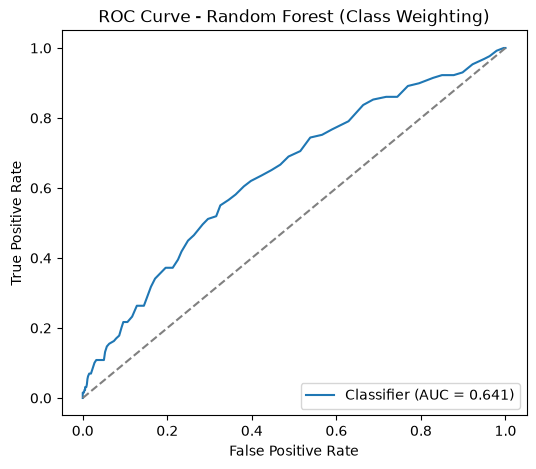

In [21]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_bal)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_bal:.3f})"
)

# Plot the reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Class Weighting)")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the class-weighted Random Forest model across different classification thresholds. The model achieved an ROC-AUC score of 0.641, representing only a marginal improvement over the baseline Random Forest model (0.639). This indicates that class weighting had little effect on the model's overall ability to distinguish between participants who developed coronary heart disease and those who did not. Nevertheless, the increase in recall observed in the previous evaluation metrics suggests that class weighting improved the detection of minority class instances by altering the model's classification behaviour rather than substantially enhancing its overall discriminative performance.

### **XGBoost with Class Weighting**

The XGBoost classifier is retrained using class weighting through the `scale_pos_weight` parameter. This parameter assigns greater importance to the minority class during training, encouraging the model to improve the detection of participants who developed coronary heart disease while enabling direct comparison with the baseline XGBoost model.

#### **Calculation of Class Weight**

The value of `scale_pos_weight` is calculated as the ratio of majority class observations to minority class observations in the training dataset. This ratio is recommended for handling class imbalance in XGBoost and ensures that greater emphasis is placed on correctly classifying minority class instances during model training.

In [22]:
# Calculate the scale_pos_weight value
negative_class = (y_train == 0).sum()
positive_class = (y_train == 1).sum()

scale_pos_weight = negative_class / positive_class

print(f"Negative class: {negative_class}")
print(f"Positive class: {positive_class}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Negative class: 2877
Positive class: 515
scale_pos_weight: 5.59


The calculated `scale_pos_weight` value of **5.59** reflects the imbalance between the majority class (2,877 observations) and the minority class (515 observations) in the training dataset. This value will be incorporated into the XGBoost model to assign greater importance to minority class observations during training, with the aim of improving the detection of participants who developed coronary heart disease.

#### **Model Training**

The XGBoost classifier is trained using the calculated `scale_pos_weight` while retaining the same baseline model configuration. This enables the effect of class weighting on predictive performance to be evaluated independently of other model parameters.

In [24]:
# Initialize the XGBoost classifier with class weighting
xgb_balanced = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

# Train the model
xgb_balanced.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


The XGBoost classifier was successfully trained using the calculated class weight. By assigning greater importance to minority class observations during training, the model is expected to improve the identification of participants who developed coronary heart disease while allowing direct comparison with the baseline XGBoost model.

#### **Model Prediction**

The trained class-weighted XGBoost model is applied to the testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are subsequently used to evaluate the effectiveness of class weighting in improving minority class detection.

In [25]:
# Generate predicted class labels
y_pred_bal = xgb_balanced.predict(X_test)

# Generate predicted probabilities for the positive class
y_pred_proba_bal = xgb_balanced.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The class-weighted XGBoost model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs will be used to assess whether class weighting improves the model's ability to identify participants who developed coronary heart disease compared with the baseline XGBoost model.

#### **Performance Metrics**

The evaluation metrics summarize the predictive performance of the class-weighted XGBoost model and facilitate comparison with the baseline XGBoost model.

In [26]:
# Calculate the evaluation metrics
accuracy_bal = accuracy_score(y_test, y_pred_bal)
precision_bal = precision_score(y_test, y_pred_bal)
recall_bal = recall_score(y_test, y_pred_bal)
f1_bal = f1_score(y_test, y_pred_bal)
roc_auc_bal = roc_auc_score(y_test, y_pred_proba_bal)

# Create a summary table
balanced_xgb_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_bal, 3),
        round(precision_bal, 3),
        round(recall_bal, 3),
        round(f1_bal, 3),
        round(roc_auc_bal, 3)
    ]
})

balanced_xgb_metrics

,Metric,Value
0,Accuracy,0.769
1,Precision,0.193
2,Recall,0.163
3,F1-score,0.176
4,ROC-AUC,0.568


The class-weighted XGBoost model produced only a modest improvement in the detection of participants who developed coronary heart disease. Compared with the baseline XGBoost model, recall increased from 0.085 to 0.163, while the F1-score improved from 0.127 to 0.176, indicating a slight improvement in minority class detection. However, these gains were accompanied by reductions in accuracy (0.822 to 0.769), precision (0.250 to 0.193), and ROC-AUC (0.605 to 0.568). The decline in ROC-AUC indicates that class weighting reduced the model's overall ability to distinguish between participants who developed coronary heart disease and those who did not. Overall, the results suggest that applying class weighting through `scale_pos_weight` provided only limited benefits for the baseline XGBoost model and did not improve its overall discriminative performance.

#### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes of the class-weighted XGBoost model by comparing the predicted class labels with the actual class labels. The results are compared with those of the baseline XGBoost model to evaluate the effect of class weighting on minority class detection.

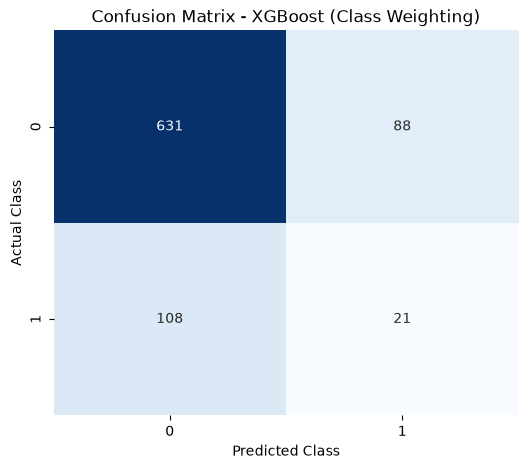

In [27]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_bal)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - XGBoost (Class Weighting)")

# Display the plot
plt.show()

The confusion matrix demonstrates that class weighting moderately improved the XGBoost model's ability to identify participants who developed coronary heart disease. Compared with the baseline XGBoost model, the number of true positive predictions increased from 11 to 21, while false negatives decreased from 118 to 108. However, this improvement was accompanied by a substantial increase in false positive predictions, which rose from 33 to 88, resulting in fewer correctly classified negative cases. Consequently, although the model became more sensitive to the minority class, the increase in false positive classifications reduced its overall predictive performance. These findings are consistent with the observed improvements in recall and F1-score, together with reductions in accuracy, precision, and ROC-AUC.

#### **Classification Report**

The classification report provides a detailed summary of the class-weighted XGBoost model's performance for each class by presenting precision, recall, F1-score, and support. These metrics facilitate comparison with the baseline XGBoost model and provide additional insight into the effect of class weighting on minority class detection.

In [28]:
# Display the classification report
print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87       719
           1       0.19      0.16      0.18       129

    accuracy                           0.77       848
   macro avg       0.52      0.52      0.52       848
weighted avg       0.75      0.77      0.76       848



The classification report indicates that class weighting produced a modest improvement in the XGBoost model's ability to identify participants who developed coronary heart disease. Compared with the baseline XGBoost model, the recall of the minority class increased from 0.09 to 0.16, while the F1-score improved from 0.13 to 0.18, demonstrating improved detection of positive cases. However, precision decreased from 0.25 to 0.19 because of an increase in false positive predictions. Although the model remained substantially more effective at classifying the majority class than the minority class, the results indicate that class weighting provided only a limited improvement in minority class detection and did not substantially enhance the overall predictive performance of the XGBoost model.

#### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is compared with that of the baseline XGBoost model to determine whether class weighting improves the model's overall discriminative ability.

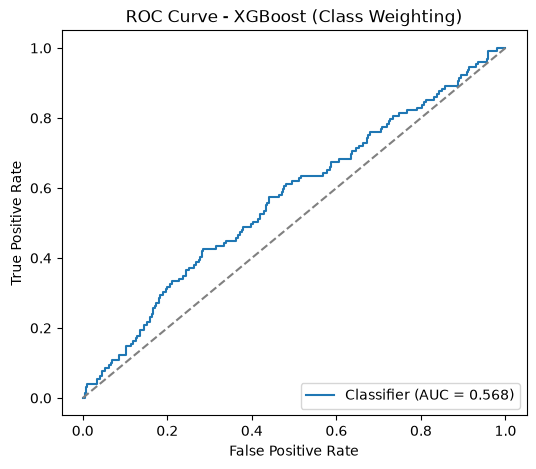

In [29]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_bal)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_bal:.3f})"
)

# Plot the reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (Class Weighting)")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the class-weighted XGBoost model across different classification thresholds. The model achieved an ROC-AUC score of 0.568, representing a decline from the baseline XGBoost model (0.605). This indicates that applying class weighting through the `scale_pos_weight` parameter reduced the model's overall ability to distinguish between participants who developed coronary heart disease and those who did not. Although previous evaluation metrics showed modest improvements in recall and F1-score, these gains were achieved at the expense of overall discriminative performance. Consequently, class weighting provided only limited benefits for the XGBoost model and was less effective than for Logistic Regression and Random Forest.

#### **Conclusion**

The class weighting experiments demonstrated that the effectiveness of cost-sensitive learning varied across the three machine learning algorithms. Logistic Regression showed the greatest improvement in detecting coronary heart disease cases, achieving substantial increases in recall and F1-score while maintaining a similar ROC-AUC score. Random Forest exhibited a more modest improvement, with higher recall but only a marginal increase in ROC-AUC. In contrast, XGBoost achieved only slight improvements in minority class detection, accompanied by reductions in accuracy, precision, and ROC-AUC.

Overall, class weighting reduced the bias towards the majority class in all three models by improving the identification of minority class instances. However, the improvements were accompanied by an increase in false positive predictions and, in some cases, reduced overall discriminative performance. These findings suggest that although class weighting can partially address class imbalance, more advanced resampling techniques such as SMOTE and SMOTE-ENN may provide greater improvements in predictive performance and minority class detection.

## **SMOTE (Synthetic Minority Over-sampling Technique)**

Synthetic Minority Over-sampling Technique (SMOTE) is applied to address the class imbalance present in the training dataset by generating synthetic examples of the minority class rather than duplicating existing observations. Unlike class weighting, SMOTE modifies the training data itself to produce a more balanced class distribution while leaving the testing dataset unchanged. The performance of Logistic Regression, Random Forest, and XGBoost trained on the SMOTE-resampled data is subsequently compared with their respective baseline and class-weighted models.

### **Applying SMOTE**

SMOTE is applied only to the training dataset to generate synthetic minority class observations. The testing dataset is intentionally left unchanged to ensure that model evaluation is performed using previously unseen data, thereby providing an unbiased assessment of predictive performance.

In [30]:
# Initialize SMOTE
smote = SMOTE(
    random_state=42
)

# Apply SMOTE to the training dataset
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("SMOTE applied successfully.")

SMOTE applied successfully.


SMOTE was successfully applied to the training dataset, generating synthetic minority class observations to produce a more balanced class distribution. The testing dataset remained unchanged to ensure an unbiased evaluation of model performance.

### **Class Distribution After SMOTE**

The class distribution of the resampled training dataset is examined to verify that SMOTE successfully balanced the majority and minority classes prior to model development.

In [31]:
# Summarize the class distribution after SMOTE
class_distribution = y_train_smote.value_counts().sort_index()

class_summary = pd.DataFrame({
    "Class": class_distribution.index,
    "Count": class_distribution.values,
    "Percentage (%)": (
        class_distribution.values /
        class_distribution.sum() * 100
    ).round(2)
})

class_summary

,Class,Count,Percentage (%)
0,0,2877,50.0
1,1,2877,50.0


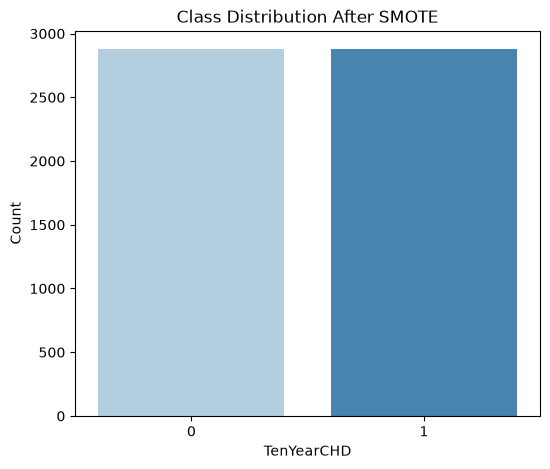

In [32]:
# Visualize the class distribution after SMOTE
plt.figure(figsize=(6, 5))

sns.countplot(
    x=y_train_smote,
    hue=y_train_smote,
    palette="Blues",
    legend=False
)

plt.xlabel("TenYearCHD")
plt.ylabel("Count")
plt.title("Class Distribution After SMOTE")

plt.show()

The class distribution confirms that SMOTE successfully balanced the training dataset by generating synthetic minority class observations. Following resampling, both the majority and minority classes contain 2,877 observations (50.0% each), thereby eliminating the class imbalance present in the original training dataset. The balanced dataset is subsequently used to train the machine learning models while the testing dataset remains unchanged for unbiased performance evaluation.

## **Logistic Regression using SMOTE**

The Logistic Regression classifier is retrained using the SMOTE-resampled training dataset. Since Logistic Regression is sensitive to differences in feature scales, the resampled training data are standardized prior to model training. The testing dataset is transformed using the same scaler to ensure consistency during model evaluation.

### **Feature Scaling**

A new StandardScaler is fitted to the SMOTE-resampled training dataset. The fitted scaler is subsequently used to transform both the resampled training dataset and the original testing dataset while preventing data leakage.

In [35]:
# Initialize a new StandardScaler
scaler_smote = StandardScaler()

# Fit the scaler on the SMOTE training data
X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)

# Transform the testing data using the fitted scaler
X_test_scaled = scaler_smote.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


Feature scaling was successfully applied to the SMOTE-resampled training dataset using a new StandardScaler. The same transformation was subsequently applied to the testing dataset to ensure consistency during model evaluation while preventing information leakage.

### **Model Training**

The Logistic Regression classifier is trained using the standardized SMOTE-resampled training dataset. The baseline model configuration is retained to ensure that any observed changes in predictive performance are attributable to SMOTE rather than modifications to the learning algorithm.

In [ ]:
# Initialize the Logistic Regression classifier
log_reg_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
log_reg_smote.fit(
    X_train_smote_scaled,
    y_train_smote
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

The Logistic Regression classifier was successfully trained using the standardized SMOTE-resampled training dataset. The model is now ready to generate predictions and evaluate the effect of synthetic oversampling on minority class detection.

### **Model Prediction**

The trained Logistic Regression model is applied to the standardized testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are subsequently used to evaluate the effect of SMOTE on model performance.

In [38]:
# Generate predicted class labels
y_pred_smote = log_reg_smote.predict(X_test_scaled)

# Generate predicted probabilities
y_pred_proba_smote = log_reg_smote.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The Logistic Regression model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs will be used to assess the effectiveness of SMOTE in improving the detection of participants who developed coronary heart disease.

### **Model Performance Evaluation**

The predictive performance of the Logistic Regression model trained on the SMOTE-resampled dataset is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. The results are subsequently compared with those of the baseline and class-weighted Logistic Regression models to determine the effectiveness of SMOTE in addressing class imbalance.

#### **Performance Metrics**

The evaluation metrics summarize the predictive performance of the Logistic Regression model trained using the SMOTE-resampled dataset and facilitate comparison with the baseline and class-weighted Logistic Regression models.

In [39]:
# Calculate the evaluation metrics
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)
roc_auc_smote = roc_auc_score(y_test, y_pred_proba_smote)

# Create a summary table
lr_smote_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_smote, 3),
        round(precision_smote, 3),
        round(recall_smote, 3),
        round(f1_smote, 3),
        round(roc_auc_smote, 3)
    ]
})

lr_smote_metrics

,Metric,Value
0,Accuracy,0.676
1,Precision,0.228
2,Recall,0.473
3,F1-score,0.307
4,ROC-AUC,0.641


The Logistic Regression model trained using the SMOTE-resampled dataset demonstrated a substantial improvement in detecting participants who developed coronary heart disease compared with the baseline Logistic Regression model. Recall increased from 0.070 to 0.473, while the F1-score improved from 0.123 to 0.307, indicating considerably better identification of minority class instances. However, these improvements were accompanied by reductions in accuracy (0.849 to 0.676), precision (0.529 to 0.228), and ROC-AUC (0.702 to 0.641). Compared with the class-weighted Logistic Regression model, SMOTE produced lower recall, F1-score, and ROC-AUC, suggesting that class weighting was more effective than synthetic oversampling for improving Logistic Regression performance on this dataset.

#### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes of the Logistic Regression model trained using the SMOTE-resampled dataset by comparing the predicted class labels with the actual class labels. The results are compared with those of the baseline and class-weighted Logistic Regression models to evaluate the effect of SMOTE on minority class detection.

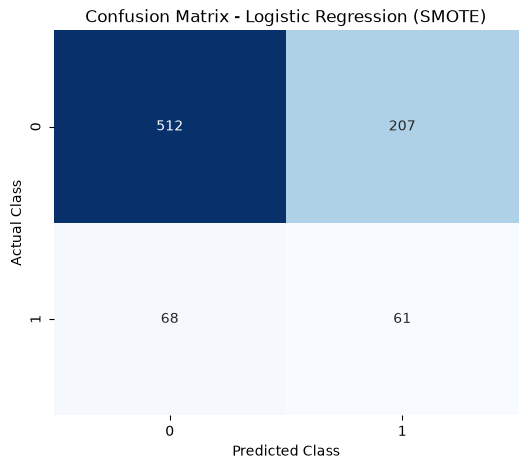

In [40]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_smote)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Logistic Regression (SMOTE)")

# Display the plot
plt.show()

The confusion matrix demonstrates that SMOTE substantially improved the Logistic Regression model's ability to identify participants who developed coronary heart disease compared with the baseline model. The number of true positive predictions increased from 9 to 61, while false negatives decreased from 120 to 68, indicating improved detection of minority class instances. Compared with the class-weighted Logistic Regression model, SMOTE produced fewer true positive predictions (61 versus 77) but also generated fewer false positives (207 versus 226) and more correctly classified negative cases (512 versus 493). These findings indicate that SMOTE achieved a more balanced trade-off between detecting coronary heart disease cases and limiting false positive classifications, although class weighting remained superior in maximizing recall.

#### **Classification Report**

The classification report provides a detailed summary of the Logistic Regression model's performance for each class by presenting precision, recall, F1-score, and support. These metrics facilitate comparison with the baseline and class-weighted Logistic Regression models and provide additional insight into the effect of SMOTE on minority class detection.

In [41]:
# Display the classification report
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.88      0.71      0.79       719
           1       0.23      0.47      0.31       129

    accuracy                           0.68       848
   macro avg       0.56      0.59      0.55       848
weighted avg       0.78      0.68      0.72       848



The classification report indicates that the Logistic Regression model trained using the SMOTE-resampled dataset substantially improved the detection of participants who developed coronary heart disease compared with the baseline Logistic Regression model. The recall of the minority class increased from 0.07 to 0.47, while the F1-score improved from 0.12 to 0.31, demonstrating a considerable improvement in identifying positive cases. Compared with the class-weighted Logistic Regression model, however, SMOTE achieved lower recall (0.47 versus 0.60) and a lower F1-score (0.31 versus 0.36), although the precision values remained similar. Overall, the findings indicate that SMOTE improved minority class detection relative to the baseline model but was less effective than class weighting for Logistic Regression on this dataset.

#### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is compared with those of the baseline and class-weighted Logistic Regression models to determine the effect of SMOTE on the model's overall discriminative ability.

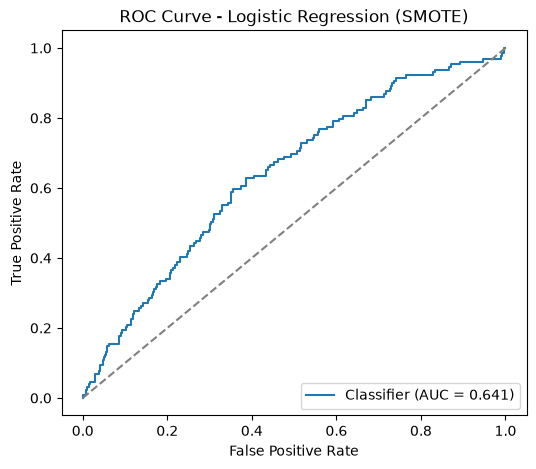

In [42]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_smote)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_smote:.3f})"
)

# Plot the no-skill reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (SMOTE)")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the Logistic Regression model trained using the SMOTE-resampled dataset across different classification thresholds. The model achieved an ROC-AUC score of 0.641, representing a decline from both the baseline Logistic Regression model (0.702) and the class-weighted Logistic Regression model (0.700). This indicates that, although SMOTE substantially improved the detection of minority class instances compared with the baseline model, it reduced the model's overall ability to distinguish between participants who developed coronary heart disease and those who did not. Consequently, SMOTE provided meaningful improvements in minority class detection but was less effective than class weighting for Logistic Regression on this dataset.

### **Conclusion**

Training the Logistic Regression model on the SMOTE-resampled dataset substantially improved minority class detection compared with the baseline model, as evidenced by higher recall and F1-score. However, compared with the class-weighted Logistic Regression model, SMOTE achieved lower recall, F1-score, and ROC-AUC, indicating that synthetic oversampling was less effective than class weighting for this algorithm. Overall, the findings suggest that class weighting remained the preferred imbalance handling strategy for Logistic Regression on the Framingham dataset.

## **Random Forest using SMOTE**

The Random Forest classifier is retrained using the SMOTE-resampled training dataset to evaluate the effect of synthetic oversampling on predictive performance. Unlike Logistic Regression, Random Forest is not sensitive to differences in feature scales; therefore, the resampled training data are used directly without feature standardization.

### **Model Training**

The Random Forest classifier is trained using the SMOTE-resampled training dataset while retaining the same baseline model configuration. This enables the effect of SMOTE on predictive performance to be evaluated independently of changes to the learning algorithm.

In [43]:
# Initialize the Random Forest classifier
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_smote.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

The Random Forest classifier was successfully trained using the SMOTE-resampled training dataset. The model is now ready to generate predictions and evaluate the effect of synthetic oversampling on minority class detection.

### **Model Prediction**

The trained Random Forest model is applied to the testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are subsequently used to evaluate the effectiveness of SMOTE in improving model performance.

In [44]:
# Generate predicted class labels
y_pred_smote = rf_smote.predict(X_test)

# Generate predicted probabilities
y_pred_proba_smote = rf_smote.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The Random Forest model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs will be used to assess the effectiveness of SMOTE in improving the detection of participants who developed coronary heart disease.

### **Model Performance Evaluation**

The predictive performance of the Random Forest model trained using the SMOTE-resampled dataset is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. The results are subsequently compared with those of the baseline and class-weighted Random Forest models to determine the effectiveness of SMOTE in addressing class imbalance.

#### **Performance Metrics**

The evaluation metrics summarize the predictive performance of the Random Forest model trained using the SMOTE-resampled dataset and facilitate comparison with the baseline and class-weighted Random Forest models.

In [45]:
# Calculate the evaluation metrics
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)
roc_auc_smote = roc_auc_score(y_test, y_pred_proba_smote)

# Create a summary table
rf_smote_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_smote, 3),
        round(precision_smote, 3),
        round(recall_smote, 3),
        round(f1_smote, 3),
        round(roc_auc_smote, 3)
    ]
})

rf_smote_metrics

,Metric,Value
0,Accuracy,0.785
1,Precision,0.252
2,Recall,0.209
3,F1-score,0.229
4,ROC-AUC,0.617


The performance metrics indicate that training the Random Forest model using the SMOTE-resampled dataset further improved the detection of participants who developed coronary heart disease compared with both the baseline and class-weighted Random Forest models. The recall increased from 0.171 to 0.209 and the F1-score improved from 0.212 to 0.229 relative to the class-weighted model, indicating enhanced identification of minority class instances. However, these improvements were accompanied by reductions in accuracy (0.785), precision (0.252), and ROC-AUC (0.617), reflecting an increase in false positive predictions and a slight decline in the model's overall discriminative ability. Overall, SMOTE improved minority class detection but introduced a trade-off between sensitivity and overall predictive performance.

### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes by comparing the predicted class labels with the actual class labels. It provides insight into the numbers of true positives, true negatives, false positives, and false negatives produced by the Random Forest model trained using the SMOTE-resampled dataset.

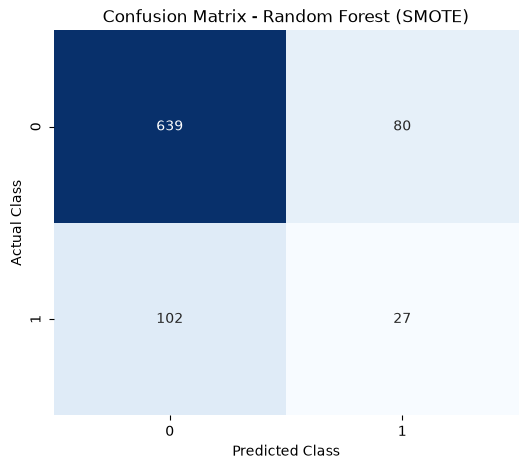

In [46]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_smote)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Random Forest (SMOTE)")

# Display the plot
plt.show()

The confusion matrix demonstrates that SMOTE improved the Random Forest model's ability to identify participants who developed coronary heart disease compared with both the baseline and class-weighted Random Forest models. The number of true positive predictions increased from 8 in the baseline model and 22 in the class-weighted model to 27, while false negatives decreased from 121 and 107 to 102, respectively. However, these improvements were accompanied by an increase in false positive predictions, which rose from 7 in the baseline model and 57 in the class-weighted model to 80, resulting in fewer correctly classified negative cases. Overall, SMOTE enhanced minority class detection and produced the highest recall among the Random Forest models, although this improvement came at the expense of reduced specificity and overall accuracy.

### **Classification Report**

The classification report provides a detailed summary of the Random Forest model's performance for each class by presenting precision, recall, F1-score, and support. These metrics facilitate comparison with the baseline and class-weighted Random Forest models and provide additional insight into the effect of SMOTE on minority class detection.

In [47]:
# Display the classification report
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       719
           1       0.25      0.21      0.23       129

    accuracy                           0.79       848
   macro avg       0.56      0.55      0.55       848
weighted avg       0.77      0.79      0.78       848



The classification report indicates that the Random Forest model trained using the SMOTE-resampled dataset improved minority class detection compared with both the baseline and class-weighted Random Forest models. For the minority class, recall increased to 0.21 and the F1-score improved to 0.23, representing the best balance between precision and recall among the three Random Forest models. Although the precision decreased slightly to 0.25 compared with the class-weighted model (0.28), the higher recall demonstrates that SMOTE enabled the model to identify more participants who developed coronary heart disease. Overall, the findings indicate that SMOTE provided the greatest improvement in minority class detection for Random Forest, albeit with an increase in false positive classifications.

### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is compared with those of the baseline and class-weighted Random Forest models to evaluate the effect of SMOTE on the model's overall discriminative ability.

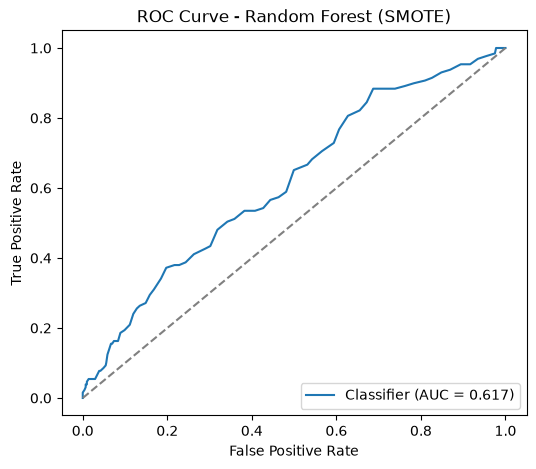

In [48]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_smote)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_smote:.3f})"
)

# Plot the no-skill reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (SMOTE)")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the Random Forest model trained using the SMOTE-resampled dataset across different classification thresholds. The model achieved an ROC-AUC score of 0.617, which is lower than both the baseline Random Forest model (0.639) and the class-weighted Random Forest model (0.641). This indicates that, although SMOTE improved the model's ability to identify participants who developed coronary heart disease by increasing recall and F1-score, it reduced the model's overall discriminative ability. Consequently, SMOTE enhanced minority class detection but introduced a trade-off between sensitivity and the model's capacity to distinguish between positive and negative cases.

### **Conclusion**

Training the Random Forest model using the SMOTE-resampled dataset improved the detection of participants who developed coronary heart disease compared with both the baseline and class-weighted Random Forest models, achieving the highest recall and F1-score among the three Random Forest variants. However, these improvements were accompanied by reductions in accuracy, precision, and ROC-AUC, indicating an increase in false positive classifications and a decline in overall discriminative ability. Overall, SMOTE enhanced minority class detection for Random Forest, although class weighting remained superior in terms of overall model discrimination.

## **XGBoost using SMOTE**

The XGBoost classifier is retrained using the SMOTE-resampled training dataset to evaluate the effect of synthetic oversampling on predictive performance. The model retains the same baseline configuration, allowing the impact of SMOTE on minority class detection to be assessed independently of changes to the learning algorithm.

### **Model Training**

The XGBoost classifier is trained using the SMOTE-resampled training dataset while maintaining the same model configuration used in the baseline experiment. This enables direct comparison between the baseline and SMOTE-enhanced XGBoost models.

In [50]:
# Initialize the XGBoost classifier
xgb_smote = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


The XGBoost classifier was successfully trained using the SMOTE-resampled training dataset. The trained model is ready to generate predictions and evaluate the effect of synthetic oversampling on minority class detection.

### **Model Prediction**

The trained XGBoost model is applied to the testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are subsequently used to evaluate the effectiveness of SMOTE in improving predictive performance.

In [51]:
# Generate predicted class labels
y_pred_smote = xgb_smote.predict(X_test)

# Generate predicted probabilities
y_pred_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The XGBoost model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs will be used to evaluate the effect of SMOTE on identifying participants who developed coronary heart disease.

### **Model Performance Evaluation**

The predictive performance of the XGBoost model trained using the SMOTE-resampled dataset is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. The results are subsequently compared with those of the baseline and class-weighted XGBoost models to determine the effectiveness of SMOTE in addressing class imbalance.

#### **Performance Metrics**

The evaluation metrics summarize the predictive performance of the XGBoost model trained using the SMOTE-resampled dataset and facilitate comparison with the baseline and class-weighted XGBoost models.

In [52]:
# Calculate the evaluation metrics
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)
roc_auc_smote = roc_auc_score(y_test, y_pred_proba_smote)

# Create a summary table
xgb_smote_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_smote, 3),
        round(precision_smote, 3),
        round(recall_smote, 3),
        round(f1_smote, 3),
        round(roc_auc_smote, 3)
    ]
})

xgb_smote_metrics

,Metric,Value
0,Accuracy,0.781
1,Precision,0.200
2,Recall,0.147
3,F1-score,0.170
4,ROC-AUC,0.562


The performance metrics indicate that training the XGBoost model using the SMOTE-resampled dataset improved minority class detection compared with the baseline XGBoost model, as evidenced by increases in recall (0.147 versus 0.085) and F1-score (0.170 versus 0.127). However, these improvements were accompanied by reductions in accuracy (0.781) and ROC-AUC (0.562), indicating a decline in the model's overall discriminative ability. Compared with the class-weighted XGBoost model, SMOTE achieved slightly higher accuracy and precision but lower recall, F1-score, and ROC-AUC. Overall, SMOTE provided only modest improvements over the baseline model and did not outperform class weighting for XGBoost on this dataset.

### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes by comparing the predicted class labels with the actual class labels. It provides insight into the numbers of true positives, true negatives, false positives, and false negatives produced by the XGBoost model trained using the SMOTE-resampled dataset.

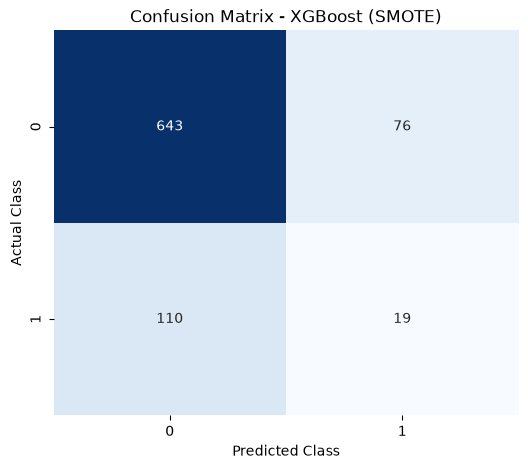

In [53]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_smote)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - XGBoost (SMOTE)")

# Display the plot
plt.show()

The confusion matrix demonstrates that SMOTE improved the XGBoost model's ability to identify participants who developed coronary heart disease compared with the baseline XGBoost model. The number of true positive predictions increased from 11 to 19, while false negatives decreased from 118 to 110, indicating improved detection of minority class instances. Compared with the class-weighted XGBoost model, however, SMOTE produced slightly fewer true positive predictions (19 versus 21) and slightly more false negatives (110 versus 108), although it reduced false positive predictions from 88 to 76 and correctly classified more negative cases (643 versus 631). Overall, SMOTE achieved a more balanced trade-off between minority class detection and false positive classification than the class-weighted model, but class weighting remained slightly superior in maximizing recall.

### **Classification Report**

The classification report provides a detailed summary of the XGBoost model's performance for each class by presenting precision, recall, F1-score, and support. These metrics facilitate comparison with the baseline and class-weighted XGBoost models and provide additional insight into the effect of SMOTE on minority class detection.

In [54]:
# Display the classification report
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       719
           1       0.20      0.15      0.17       129

    accuracy                           0.78       848
   macro avg       0.53      0.52      0.52       848
weighted avg       0.75      0.78      0.77       848



The classification report indicates that the XGBoost model trained using the SMOTE-resampled dataset improved minority class detection compared with the baseline XGBoost model. For the minority class, recall increased from 0.09 to 0.15 and the F1-score improved from 0.13 to 0.17, demonstrating improved identification of participants who developed coronary heart disease. Compared with the class-weighted XGBoost model, however, SMOTE achieved slightly higher precision (0.20 versus 0.19) but slightly lower recall (0.15 versus 0.16) and F1-score (0.17 versus 0.18). Overall, the findings indicate that SMOTE improved performance over the baseline model but did not surpass class weighting in detecting minority class instances.

### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is compared with those of the baseline and class-weighted XGBoost models to evaluate the effect of SMOTE on the model's overall discriminative ability.

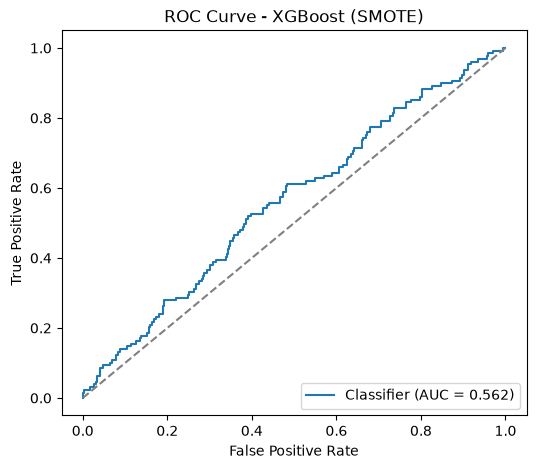

In [55]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_smote)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_smote:.3f})"
)

# Plot the no-skill reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (SMOTE)")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the XGBoost model trained using the SMOTE-resampled dataset across different classification thresholds. The model achieved an ROC-AUC score of 0.562, which is lower than the baseline XGBoost model (0.605) and marginally lower than the class-weighted XGBoost model (0.568). This indicates that, although SMOTE improved minority class detection relative to the baseline model, it slightly reduced the model's overall ability to distinguish between participants who developed coronary heart disease and those who did not. Overall, SMOTE produced predictive performance comparable to class weighting but did not provide a meaningful improvement in overall model discrimination.

### **Conclusion**

Training the XGBoost model using the SMOTE-resampled dataset improved minority class detection compared with the baseline model, resulting in higher recall and F1-score. However, these improvements were accompanied by reductions in accuracy and ROC-AUC, indicating a decline in overall discriminative performance. Compared with the class-weighted XGBoost model, SMOTE achieved similar predictive performance but did not produce meaningful improvements in recall, F1-score, or ROC-AUC. Overall, class weighting remained the preferred imbalance handling strategy for XGBoost on the Framingham dataset.

### **Resampling the Training Dataset**

The SMOTE-ENN technique is applied only to the training dataset to balance the class distribution while preserving the original testing dataset for unbiased model evaluation.

In [56]:
# Initialize the SMOTE-ENN resampler
smoteenn = SMOTEENN(random_state=42)

# Apply SMOTE-ENN to the training data
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(
    X_train,
    y_train
)

print("SMOTE-ENN resampling completed successfully.")

SMOTE-ENN resampling completed successfully.


The training dataset was successfully resampled using the SMOTE-ENN technique. The resulting dataset contains a balanced representation of both classes after synthetic oversampling and noise reduction, making it suitable for evaluating the effect of hybrid resampling on predictive performance.

### **Class Distribution After SMOTE-ENN**

The class distribution is examined after applying SMOTE-ENN to verify the effectiveness of the hybrid resampling technique in balancing the training dataset.

In [57]:
# Calculate the class distribution
class_distribution = y_train_smoteenn.value_counts().sort_index()

class_summary = pd.DataFrame({
    "Class": class_distribution.index,
    "Count": class_distribution.values,
    "Percentage (%)": (
        class_distribution.values /
        class_distribution.sum() * 100
    ).round(2)
})

class_summary

,Class,Count,Percentage (%)
0,0,1587,37.13
1,1,2687,62.87


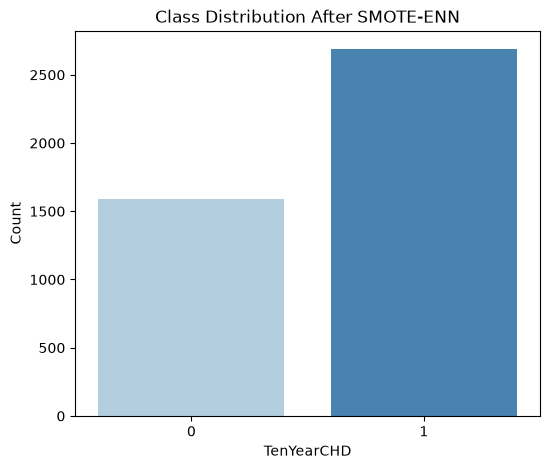

In [58]:
# Visualize the class distribution after SMOTE-ENN
plt.figure(figsize=(6, 5))

sns.countplot(
    x=y_train_smoteenn,
    hue=y_train_smoteenn,
    palette="Blues",
    legend=False
)

plt.xlabel("TenYearCHD")
plt.ylabel("Count")
plt.title("Class Distribution After SMOTE-ENN")

plt.show()

## **Logistic Regression using SMOTE-ENN**

The Logistic Regression classifier is trained using the SMOTE-ENN-resampled training dataset to evaluate the effectiveness of the hybrid resampling technique in improving minority class detection. Because Logistic Regression is sensitive to differences in feature scales, the SMOTE-ENN-resampled training data are standardized before model training, while the same transformation is applied to the testing dataset.

### **Feature Scaling**

The SMOTE-ENN-resampled training dataset is standardized using the StandardScaler prior to model training. The scaler is fitted only on the training data and then applied to the testing dataset to prevent data leakage while ensuring that all predictor variables are measured on a comparable scale.

In [62]:
# Initialize a StandardScaler
scaler_smoteenn = StandardScaler()

# Fit the scaler on the SMOTE-ENN training data
X_train_smoteenn_scaled = scaler_smoteenn.fit_transform(
    X_train_smoteenn
)

# Apply the same transformation to the testing data
X_test_smoteenn_scaled = scaler_smoteenn.transform(
    X_test
)

print("SMOTE-ENN data standardized successfully.")

SMOTE-ENN data standardized successfully.


The SMOTE-ENN-resampled training dataset was successfully standardized. The same scaling transformation was subsequently applied to the testing dataset, ensuring consistency between training and testing data while preventing information leakage.

### **Model Training**

The Logistic Regression classifier is trained using the standardized SMOTE-ENN-resampled training dataset while maintaining the same model configuration used in the previous experiments. This enables direct comparison with the baseline, class-weighted, and SMOTE-based Logistic Regression models.

In [63]:
# Initialize the Logistic Regression classifier
log_reg_smoteenn = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the standardized SMOTE-ENN training data
log_reg_smoteenn.fit(
    X_train_smoteenn_scaled,
    y_train_smoteenn
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

The Logistic Regression classifier was successfully trained using the standardized SMOTE-ENN-resampled training dataset. The trained model is ready to generate predictions and evaluate the effectiveness of hybrid resampling on minority class detection.

### **Model Prediction**

The trained Logistic Regression model is applied to the standardized testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are subsequently used to evaluate the effect of SMOTE-ENN on predictive performance.

In [64]:
# Generate predicted class labels
y_pred_smoteenn = log_reg_smoteenn.predict(
    X_test_smoteenn_scaled
)

# Generate predicted probabilities
y_pred_proba_smoteenn = log_reg_smoteenn.predict_proba(
    X_test_smoteenn_scaled
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The Logistic Regression model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs will be used to evaluate the effectiveness of the SMOTE-ENN technique in improving the detection of participants who developed coronary heart disease.

### **Model Performance Evaluation**

The predictive performance of the Logistic Regression model trained using the SMOTE-ENN-resampled dataset is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. The results are compared with those of the baseline, class-weighted, and SMOTE-based Logistic Regression models to determine the effectiveness of SMOTE-ENN in addressing class imbalance.


#### **Performance Metrics**

The evaluation metrics summarize the predictive performance of the Logistic Regression model trained using the SMOTE-ENN-resampled dataset and facilitate comparison with the previous Logistic Regression experiments.

In [65]:
# Calculate the evaluation metrics
accuracy_smoteenn = accuracy_score(y_test, y_pred_smoteenn)
precision_smoteenn = precision_score(y_test, y_pred_smoteenn)
recall_smoteenn = recall_score(y_test, y_pred_smoteenn)
f1_smoteenn = f1_score(y_test, y_pred_smoteenn)
roc_auc_smoteenn = roc_auc_score(y_test, y_pred_proba_smoteenn)

# Create a summary table
lr_smoteenn_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_smoteenn, 3),
        round(precision_smoteenn, 3),
        round(recall_smoteenn, 3),
        round(f1_smoteenn, 3),
        round(roc_auc_smoteenn, 3)
    ]
})

lr_smoteenn_metrics

,Metric,Value
0,Accuracy,0.550
1,Precision,0.211
2,Recall,0.713
3,F1-score,0.325
4,ROC-AUC,0.661


The Logistic Regression model trained using the SMOTE-ENN-resampled dataset achieved a recall of 0.713, indicating that it correctly identified a large proportion of participants who developed coronary heart disease. This represents the highest recall among the Logistic Regression variants evaluated so far. However, the model recorded a low precision of 0.211 and an accuracy of 0.550, indicating that the improved sensitivity was accompanied by a substantial increase in false positive predictions.

The F1-score of 0.325 reflects a moderate balance between precision and recall, while the ROC-AUC score of 0.661 indicates modest overall discriminative ability. Compared with class weighting, SMOTE-ENN produced higher recall but lower accuracy, precision, F1-score, and ROC-AUC. Overall, SMOTE-ENN was effective in maximizing minority class detection, although this improvement came at the expense of overall classification performance.

### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes by comparing the predicted class labels with the actual class labels. It provides insight into the numbers of true positives, true negatives, false positives, and false negatives produced by the Logistic Regression model trained using the SMOTE-ENN-resampled dataset.

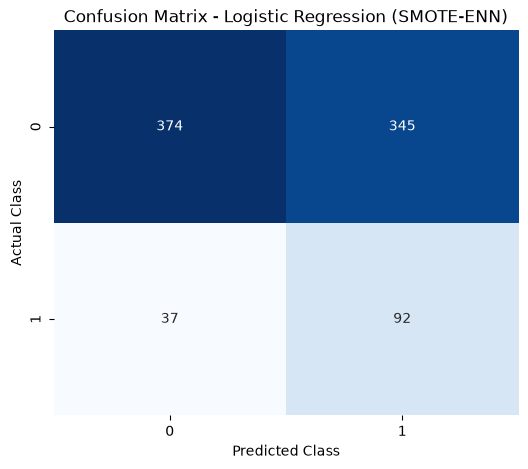

In [66]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_smoteenn)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Logistic Regression (SMOTE-ENN)")

# Display the plot
plt.show()

The confusion matrix demonstrates that the Logistic Regression model trained using the SMOTE-ENN-resampled dataset substantially improved the detection of participants who developed coronary heart disease. Compared with the baseline Logistic Regression model, the number of true positive predictions increased markedly from 9 to 92, while false negatives decreased from 120 to 37, indicating a considerable improvement in minority class detection.

Compared with the Logistic Regression models trained using class weighting and SMOTE, the SMOTE-ENN model produced the highest number of true positive predictions and the fewest false negatives. However, this improvement was accompanied by a substantial increase in false positive predictions, which rose to 345, resulting in fewer correctly classified negative cases. Overall, SMOTE-ENN maximized sensitivity to the minority class but achieved this at the expense of specificity and overall classification accuracy.

### **Classification Report**

The classification report provides a detailed summary of the Logistic Regression model's performance for each class by presenting precision, recall, F1-score, and support. These metrics facilitate comparison with the baseline, class-weighted, and SMOTE-based Logistic Regression models and provide additional insight into the effect of SMOTE-ENN on minority class detection.

In [67]:
# Display the classification report
print(classification_report(y_test, y_pred_smoteenn))

              precision    recall  f1-score   support

           0       0.91      0.52      0.66       719
           1       0.21      0.71      0.33       129

    accuracy                           0.55       848
   macro avg       0.56      0.62      0.49       848
weighted avg       0.80      0.55      0.61       848



The classification report indicates that the Logistic Regression model trained using the SMOTE-ENN-resampled dataset achieved the highest minority class detection performance among all Logistic Regression models evaluated. For the minority class, recall increased substantially to 0.71, while the F1-score improved to 0.33, reflecting the strongest balance between precision and recall obtained for this algorithm. Compared with the baseline, class-weighted, and SMOTE-based Logistic Regression models, SMOTE-ENN correctly identified the greatest proportion of participants who developed coronary heart disease. However, the precision remained relatively low (0.21), indicating that the improvement in sensitivity was accompanied by a considerable increase in false positive predictions. Overall, SMOTE-ENN proved to be the most effective imbalance-handling technique for maximizing minority class detection in the Logistic Regression model.

### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is compared with those of the baseline, class-weighted, and SMOTE-based Logistic Regression models to evaluate the effect of SMOTE-ENN on the model's overall discriminative ability.

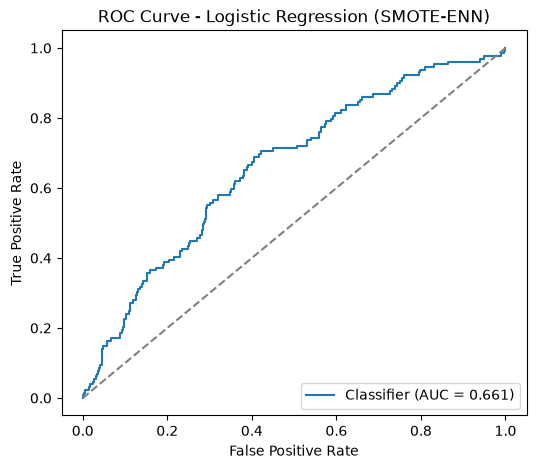

In [68]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_smoteenn)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_smoteenn:.3f})"
)

# Plot the no-skill reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (SMOTE-ENN)")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the Logistic Regression model trained using the SMOTE-ENN-resampled dataset across different classification thresholds. The model achieved an ROC-AUC score of 0.661, indicating moderate ability to distinguish between participants who developed coronary heart disease and those who did not. Compared with the SMOTE-based Logistic Regression model (ROC-AUC = 0.641), SMOTE-ENN provided an improvement in overall discriminative performance. However, its ROC-AUC remained lower than those of the baseline (0.696) and class-weighted (0.700) Logistic Regression models. Despite this reduction in overall discrimination, SMOTE-ENN achieved the highest recall and F1-score among the Logistic Regression models, demonstrating that the hybrid resampling technique substantially improved minority class detection while accepting a reduction in specificity.

### **Conclusion**

Training the Logistic Regression model using the SMOTE-ENN-resampled dataset produced the strongest minority class detection performance among all Logistic Regression experiments. The model achieved the highest recall and F1-score by correctly identifying substantially more participants who developed coronary heart disease than the baseline, class-weighted, and SMOTE-based Logistic Regression models. However, these improvements were accompanied by reduced accuracy, precision, and overall discriminative ability due to a considerable increase in false positive predictions. Overall, SMOTE-ENN proved to be the most effective imbalance-handling technique for maximizing sensitivity in the Logistic Regression model, making it particularly suitable when minimizing missed coronary heart disease cases is prioritized over reducing false positive classifications.

## **Random Forest using SMOTE-ENN**

The Random Forest classifier is trained using the SMOTE-ENN-resampled training dataset to evaluate the effectiveness of the hybrid resampling technique in improving minority class detection. Since Random Forest is a tree-based algorithm, feature standardization is not required because the model is not affected by differences in feature scales.

### **Model Training**

The Random Forest classifier is trained using the SMOTE-ENN-resampled training dataset while maintaining the same model configuration adopted in the previous experiments. This enables direct comparison with the baseline, class-weighted, and SMOTE-based Random Forest models.

In [69]:
# Initialize the Random Forest classifier
rf_smoteenn = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model using the SMOTE-ENN training data
rf_smoteenn.fit(
    X_train_smoteenn,
    y_train_smoteenn
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

The Random Forest classifier was successfully trained using the SMOTE-ENN-resampled training dataset. The trained model is ready to generate predictions and evaluate the effectiveness of the hybrid resampling technique in improving minority class detection.

### **Model Prediction**

The trained Random Forest model is applied to the testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are subsequently used to evaluate the predictive performance of the model trained using the SMOTE-ENN-resampled dataset.

In [70]:
# Generate predicted class labels
y_pred_smoteenn = rf_smoteenn.predict(X_test)

# Generate predicted probabilities
y_pred_proba_smoteenn = rf_smoteenn.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The Random Forest model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs will be used to evaluate the effectiveness of the SMOTE-ENN technique in improving the detection of participants who developed coronary heart disease.

### **Model Performance Evaluation**

The predictive performance of the Random Forest model trained using the SMOTE-ENN-resampled dataset is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. The results are compared with those of the baseline, class-weighted, and SMOTE-based Random Forest models to determine the effectiveness of SMOTE-ENN in addressing class imbalance.


#### **Performance Metrics**

The evaluation metrics summarize the predictive performance of the Random Forest model trained using the SMOTE-ENN-resampled dataset and facilitate comparison with the previous Random Forest experiments.

In [71]:
# Calculate the evaluation metrics
accuracy_smoteenn = accuracy_score(y_test, y_pred_smoteenn)
precision_smoteenn = precision_score(y_test, y_pred_smoteenn)
recall_smoteenn = recall_score(y_test, y_pred_smoteenn)
f1_smoteenn = f1_score(y_test, y_pred_smoteenn)
roc_auc_smoteenn = roc_auc_score(y_test, y_pred_proba_smoteenn)

# Create a summary table
rf_smoteenn_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_smoteenn, 3),
        round(precision_smoteenn, 3),
        round(recall_smoteenn, 3),
        round(f1_smoteenn, 3),
        round(roc_auc_smoteenn, 3)
    ]
})

rf_smoteenn_metrics

,Metric,Value
0,Accuracy,0.639
1,Precision,0.226
2,Recall,0.566
3,F1-score,0.323
4,ROC-AUC,0.654


The Random Forest model trained using the SMOTE-ENN-resampled dataset achieved substantial improvements in minority class detection compared with the previous Random Forest models. The model recorded a recall of 0.566, representing the highest recall among all Random Forest experiments, while the F1-score increased to 0.323, indicating a considerably improved balance between precision and recall.

Although the model's accuracy decreased to 0.639 due to an increase in positive predictions, the ROC-AUC score improved to 0.654, representing the strongest overall discriminative performance among the Random Forest models evaluated. These findings suggest that combining SMOTE with Edited Nearest Neighbours substantially enhanced the Random Forest model's ability to identify participants who developed coronary heart disease while maintaining better overall discrimination than the baseline, class-weighted, and SMOTE-based Random Forest models.

### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes by comparing the predicted class labels with the actual class labels. It provides insight into the numbers of true positives, true negatives, false positives, and false negatives produced by the Random Forest model trained using the SMOTE-ENN-resampled dataset.

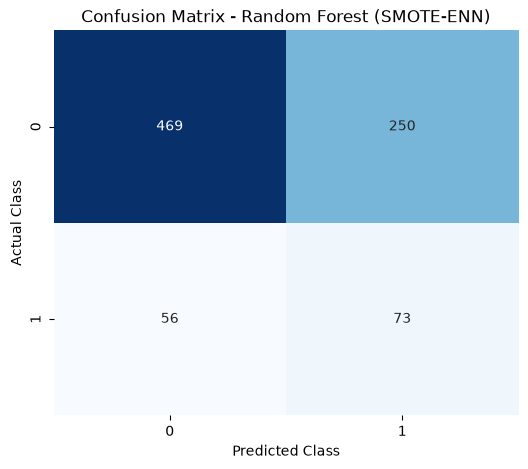

In [72]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_smoteenn)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Random Forest (SMOTE-ENN)")

# Display the plot
plt.show()

The confusion matrix demonstrates that the Random Forest model trained using the SMOTE-ENN-resampled dataset substantially improved the detection of participants who developed coronary heart disease. Compared with the baseline Random Forest model, the number of true positive predictions increased markedly from 8 to 73, while false negatives decreased from 121 to 56, indicating a considerable improvement in minority class detection.

Compared with the class-weighted and SMOTE-based Random Forest models, the SMOTE-ENN model achieved the highest number of true positive predictions and the fewest false negatives, demonstrating superior sensitivity to the minority class. However, these improvements were accompanied by a substantial increase in false positive predictions, which rose to 250, resulting in fewer correctly classified negative cases. Overall, SMOTE-ENN produced the strongest minority class detection among the Random Forest models but achieved this at the expense of specificity and overall classification accuracy.

### **Classification Report**

The classification report provides a detailed summary of the Random Forest model's performance for each class by presenting precision, recall, F1-score, and support. These metrics facilitate comparison with the baseline, class-weighted, and SMOTE-based Random Forest models and provide additional insight into the effect of SMOTE-ENN on minority class detection.

In [73]:
# Display the classification report
print(classification_report(y_test, y_pred_smoteenn))

              precision    recall  f1-score   support

           0       0.89      0.65      0.75       719
           1       0.23      0.57      0.32       129

    accuracy                           0.64       848
   macro avg       0.56      0.61      0.54       848
weighted avg       0.79      0.64      0.69       848



The classification report indicates that the Random Forest model trained using the SMOTE-ENN-resampled dataset achieved the strongest minority class detection performance among all Random Forest models evaluated. For the minority class, recall increased substantially to 0.57, while the F1-score improved to 0.32, representing the highest values obtained across the baseline, class-weighted, and SMOTE-based Random Forest models. These findings demonstrate that SMOTE-ENN enabled the model to identify a considerably larger proportion of participants who developed coronary heart disease.

However, the improvement in sensitivity was accompanied by a relatively low precision of 0.23, indicating that many participants predicted as having coronary heart disease did not actually belong to the positive class. Overall, SMOTE-ENN provided the best balance between precision and recall among the Random Forest models, making it the most effective imbalance-handling technique for improving minority class detection in this algorithm.

### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is compared with those of the baseline, class-weighted, and SMOTE-based Random Forest models to evaluate the effect of SMOTE-ENN on the model's overall discriminative ability.

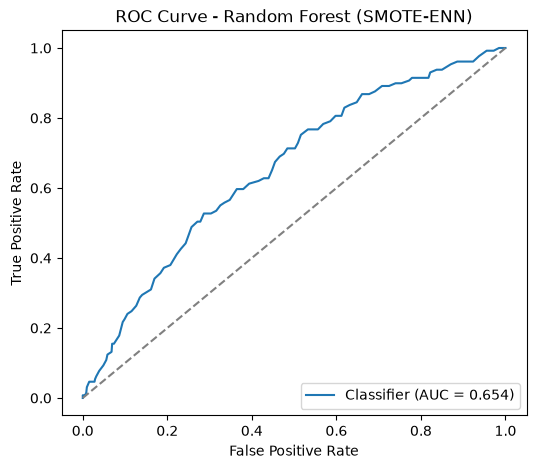

In [74]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_smoteenn)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_smoteenn:.3f})"
)

# Plot the no-skill reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (SMOTE-ENN)")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the Random Forest model trained using the SMOTE-ENN-resampled dataset across different classification thresholds. The model achieved an ROC-AUC score of 0.654, representing the highest discriminative performance among all Random Forest models evaluated. Compared with the baseline (ROC-AUC = 0.639), class-weighted (ROC-AUC = 0.641), and SMOTE-based (ROC-AUC = 0.617) Random Forest models, SMOTE-ENN provided the greatest overall ability to distinguish between participants who developed coronary heart disease and those who did not. Together with its superior recall and F1-score, these findings indicate that the hybrid SMOTE-ENN technique substantially enhanced the Random Forest model's effectiveness in detecting minority class instances while maintaining the strongest overall predictive performance among the Random Forest experiments.

### **Conclusion**

Training the Random Forest model using the SMOTE-ENN-resampled dataset produced the strongest overall predictive performance among all Random Forest experiments. The model achieved the highest recall, F1-score, and ROC-AUC while substantially improving the detection of participants who developed coronary heart disease. Although these improvements were accompanied by reductions in accuracy and specificity due to an increase in false positive predictions, the enhanced sensitivity to the minority class makes SMOTE-ENN the most effective imbalance-handling technique for the Random Forest classifier on the Framingham dataset.

## **XGBoost using SMOTE-ENN**

The XGBoost classifier is trained using the SMOTE-ENN-resampled training dataset to evaluate the effectiveness of the hybrid resampling technique in improving minority class detection. Since XGBoost is a tree-based ensemble algorithm, feature standardization is not required because the model is not affected by differences in feature scales.

### **Model Training**

The XGBoost classifier is trained using the SMOTE-ENN-resampled training dataset while maintaining the same model configuration adopted in the previous experiments. This enables direct comparison with the baseline, class-weighted, and SMOTE-based XGBoost models.

In [75]:
# Initialize the XGBoost classifier
xgb_smoteenn = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

# Train the model using the SMOTE-ENN training data
xgb_smoteenn.fit(
    X_train_smoteenn,
    y_train_smoteenn
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


The XGBoost classifier was successfully trained using the SMOTE-ENN-resampled training dataset. The trained model is ready to generate predictions and evaluate the effectiveness of the hybrid resampling technique in improving minority class detection.

### **Model Prediction**

The trained XGBoost model is applied to the testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are subsequently used to evaluate the predictive performance of the model trained using the SMOTE-ENN-resampled dataset.

In [76]:
# Generate predicted class labels
y_pred_smoteenn = xgb_smoteenn.predict(X_test)

# Generate predicted probabilities
y_pred_proba_smoteenn = xgb_smoteenn.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The XGBoost model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs will be used to evaluate the effectiveness of the SMOTE-ENN technique in improving the detection of participants who developed coronary heart disease.

### **Model Performance Evaluation**

The predictive performance of the XGBoost model trained using the SMOTE-ENN-resampled dataset is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. The results are compared with those of the baseline, class-weighted, and SMOTE-based XGBoost models to determine the effectiveness of SMOTE-ENN in addressing class imbalance.


#### **Performance Metrics**

The evaluation metrics summarize the predictive performance of the XGBoost model trained using the SMOTE-ENN-resampled dataset and facilitate comparison with the previous XGBoost experiments.

In [77]:
# Calculate the evaluation metrics
accuracy_smoteenn = accuracy_score(y_test, y_pred_smoteenn)
precision_smoteenn = precision_score(y_test, y_pred_smoteenn)
recall_smoteenn = recall_score(y_test, y_pred_smoteenn)
f1_smoteenn = f1_score(y_test, y_pred_smoteenn)
roc_auc_smoteenn = roc_auc_score(y_test, y_pred_proba_smoteenn)

# Create a summary table
xgb_smoteenn_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy_smoteenn, 3),
        round(precision_smoteenn, 3),
        round(recall_smoteenn, 3),
        round(f1_smoteenn, 3),
        round(roc_auc_smoteenn, 3)
    ]
})

xgb_smoteenn_metrics

,Metric,Value
0,Accuracy,0.669
1,Precision,0.223
2,Recall,0.473
3,F1-score,0.303
4,ROC-AUC,0.617


The XGBoost model trained using the SMOTE-ENN-resampled dataset demonstrated substantial improvements in minority class detection compared with the previous XGBoost models. The model achieved a recall of 0.473, representing the highest recall among all XGBoost experiments, while the F1-score increased to 0.303, indicating a markedly improved balance between precision and recall.

Although the model's accuracy decreased to 0.669 due to an increase in positive predictions, the ROC-AUC score improved to 0.617, representing the highest overall discriminative performance among the XGBoost models evaluated. These findings indicate that the hybrid SMOTE-ENN technique substantially enhanced the XGBoost model's ability to identify participants who developed coronary heart disease while improving its overall ability to distinguish between positive and negative cases.

### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes by comparing the predicted class labels with the actual class labels. It provides insight into the numbers of true positives, true negatives, false positives, and false negatives produced by the XGBoost model trained using the SMOTE-ENN-resampled dataset.

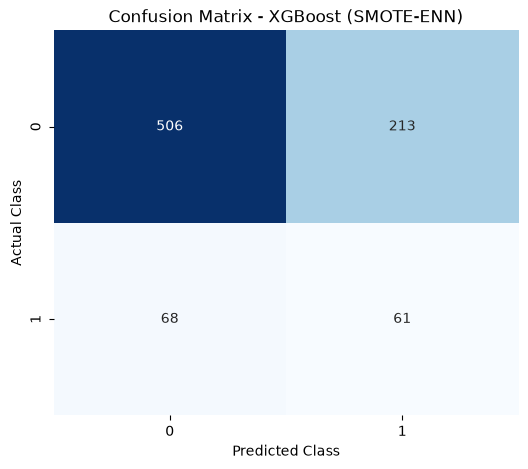

In [78]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_smoteenn)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

# Customize the plot
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - XGBoost (SMOTE-ENN)")

# Display the plot
plt.show()

The confusion matrix demonstrates that the XGBoost model trained using the SMOTE-ENN-resampled dataset substantially improved the detection of participants who developed coronary heart disease. Compared with the baseline XGBoost model, the number of true positive predictions increased markedly from 11 to 61, while false negatives decreased from 118 to 68, indicating a considerable improvement in minority class detection.

Compared with the class-weighted and SMOTE-based XGBoost models, the SMOTE-ENN model achieved the highest number of true positive predictions and the fewest false negatives, demonstrating superior sensitivity to the minority class. However, these improvements were accompanied by a substantial increase in false positive predictions, which rose to 213, resulting in fewer correctly classified negative cases. Overall, SMOTE-ENN produced the strongest minority class detection among the XGBoost models but achieved this at the expense of specificity and overall classification accuracy.

### **Classification Report**

The classification report provides a detailed summary of the XGBoost model's performance for each class by presenting precision, recall, F1-score, and support. These metrics facilitate comparison with the baseline, class-weighted, and SMOTE-based XGBoost models and provide additional insight into the effect of SMOTE-ENN on minority class detection.

In [79]:
# Display the classification report
print(classification_report(y_test, y_pred_smoteenn))

              precision    recall  f1-score   support

           0       0.88      0.70      0.78       719
           1       0.22      0.47      0.30       129

    accuracy                           0.67       848
   macro avg       0.55      0.59      0.54       848
weighted avg       0.78      0.67      0.71       848



The classification report indicates that the XGBoost model trained using the SMOTE-ENN-resampled dataset achieved the strongest minority class detection performance among all XGBoost models evaluated. For the minority class, recall increased substantially to 0.47, while the F1-score improved to 0.30, representing the highest values obtained across the baseline, class-weighted, and SMOTE-based XGBoost models. These findings demonstrate that SMOTE-ENN enabled the model to identify a considerably larger proportion of participants who developed coronary heart disease.

However, the improvement in sensitivity was accompanied by a relatively low precision of 0.22, indicating that many participants predicted as having coronary heart disease did not actually belong to the positive class. Overall, SMOTE-ENN provided the best balance between precision and recall among the XGBoost models, making it the most effective imbalance-handling technique for improving minority class detection in this algorithm.

### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate (1 − specificity) across different classification thresholds. The ROC-AUC score is compared with those of the baseline, class-weighted, and SMOTE-based XGBoost models to evaluate the effect of SMOTE-ENN on the model's overall discriminative ability.

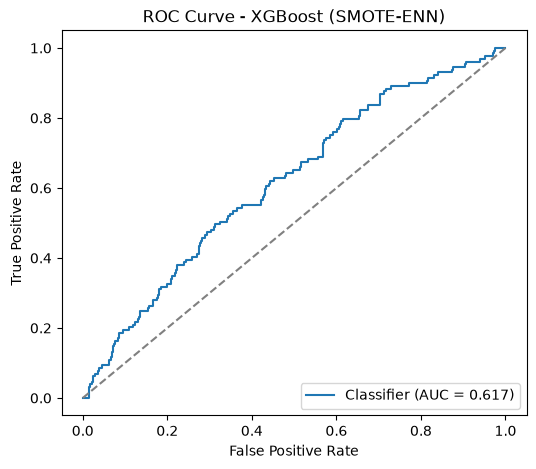

In [80]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_smoteenn)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_smoteenn:.3f})"
)

# Plot the no-skill reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (SMOTE-ENN)")
plt.legend(loc="lower right")

# Display the plot
plt.show()

The ROC curve demonstrates the discriminative ability of the XGBoost model trained using the SMOTE-ENN-resampled dataset across different classification thresholds. The model achieved an ROC-AUC score of 0.617, representing the highest discriminative performance among all XGBoost models evaluated. Compared with the baseline (ROC-AUC = 0.605), class-weighted (ROC-AUC = 0.568), and SMOTE-based (ROC-AUC = 0.562) XGBoost models, SMOTE-ENN provided the greatest overall ability to distinguish between participants who developed coronary heart disease and those who did not. Together with its superior recall and F1-score, these findings indicate that the hybrid SMOTE-ENN technique substantially enhanced the XGBoost model's effectiveness in detecting minority class instances while maintaining the strongest overall predictive performance among the XGBoost experiments.

### **Conclusion**

Training the XGBoost model using the SMOTE-ENN-resampled dataset produced the strongest overall predictive performance among all XGBoost experiments. The model achieved the highest recall, F1-score, and ROC-AUC while substantially improving the detection of participants who developed coronary heart disease compared with the baseline, class-weighted, and SMOTE-based XGBoost models. Although these improvements were accompanied by reductions in accuracy and precision due to an increase in false positive predictions, SMOTE-ENN proved to be the most effective imbalance-handling technique for enhancing minority class detection in the XGBoost classifier.

## **Summary of Findings**

This notebook investigated the effects of class weighting, SMOTE, and SMOTE-ENN on the performance of Logistic Regression, Random Forest, and XGBoost models for predicting ten-year coronary heart disease. The imbalance-handling techniques generally improved the detection of participants who developed coronary heart disease compared with the baseline models, although these improvements were often accompanied by reductions in accuracy and precision due to an increase in false positive predictions.

Class weighting produced the strongest improvement for Logistic Regression, substantially increasing recall while maintaining a similar ROC-AUC score. For Random Forest, SMOTE improved minority class detection, but SMOTE-ENN produced the highest recall, F1-score, and ROC-AUC among the Random Forest variants. Similarly, SMOTE-ENN produced the strongest minority class detection and overall discriminative performance among the XGBoost variants.

Overall, SMOTE-ENN was the most effective imbalance-handling technique for Random Forest and XGBoost, while class weighting remained highly competitive for Logistic Regression. These findings confirm that the effectiveness of imbalance-handling techniques depends on the underlying machine learning algorithm. The best-performing variants from this notebook will be subjected to hyperparameter tuning in the next stage of the study.

### **Model Persistence**

The best-performing untuned models obtained from the class imbalance handling experiments are saved to the models directory using the `joblib` library. Persisting the trained models ensures reproducibility, enables future model comparison with the hyperparameter-tuned models, and facilitates subsequent stages of the study, including model deployment and explainability.

In [82]:
# Save the untuned SMOTE-ENN models
joblib.dump(
    log_reg_smoteenn,
    "../models/logistic_regression_smoteenn.pkl"
)

joblib.dump(
    rf_smoteenn,
    "../models/random_forest_smoteenn.pkl"
)

joblib.dump(
    xgb_smoteenn,
    "../models/xgboost_smoteenn.pkl"
)

print("Untuned SMOTE-ENN models successfully saved to the models directory.")

Untuned SMOTE-ENN models successfully saved to the models directory.


The untuned Logistic Regression, Random Forest, and XGBoost models trained using the SMOTE-ENN-resampled dataset were successfully saved to the models directory. These models provide a reproducible checkpoint of the best-performing untuned classifiers and will serve as reference models for hyperparameter tuning and subsequent comparative analyses.

**Next Phase:** Hyperparameter Tuning